In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
df = pd.read_csv("smartcart_customers.csv")

In [116]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [117]:
df.shape

(2240, 22)

In [118]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle Missing Values

In [119]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [120]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## 2. Feature Engineering

In [137]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [138]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [139]:
# Spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]  + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [140]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [141]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [142]:
# Marital Status
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

# Drop Columns

In [143]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Total_Children,Age,Total_Spending,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,663,0,69,1617,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,113,2,72,27,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,312,0,61,776,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,139,1,42,53,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,161,1,45,422,Partner


In [144]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [145]:
df_cleaned.shape

(2240, 15)

In [146]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Total_Children,Age,Total_Spending,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,663,0,69,1617,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,113,2,72,27,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,312,0,61,776,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,139,1,42,53,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,161,1,45,422,Partner


# Outliers

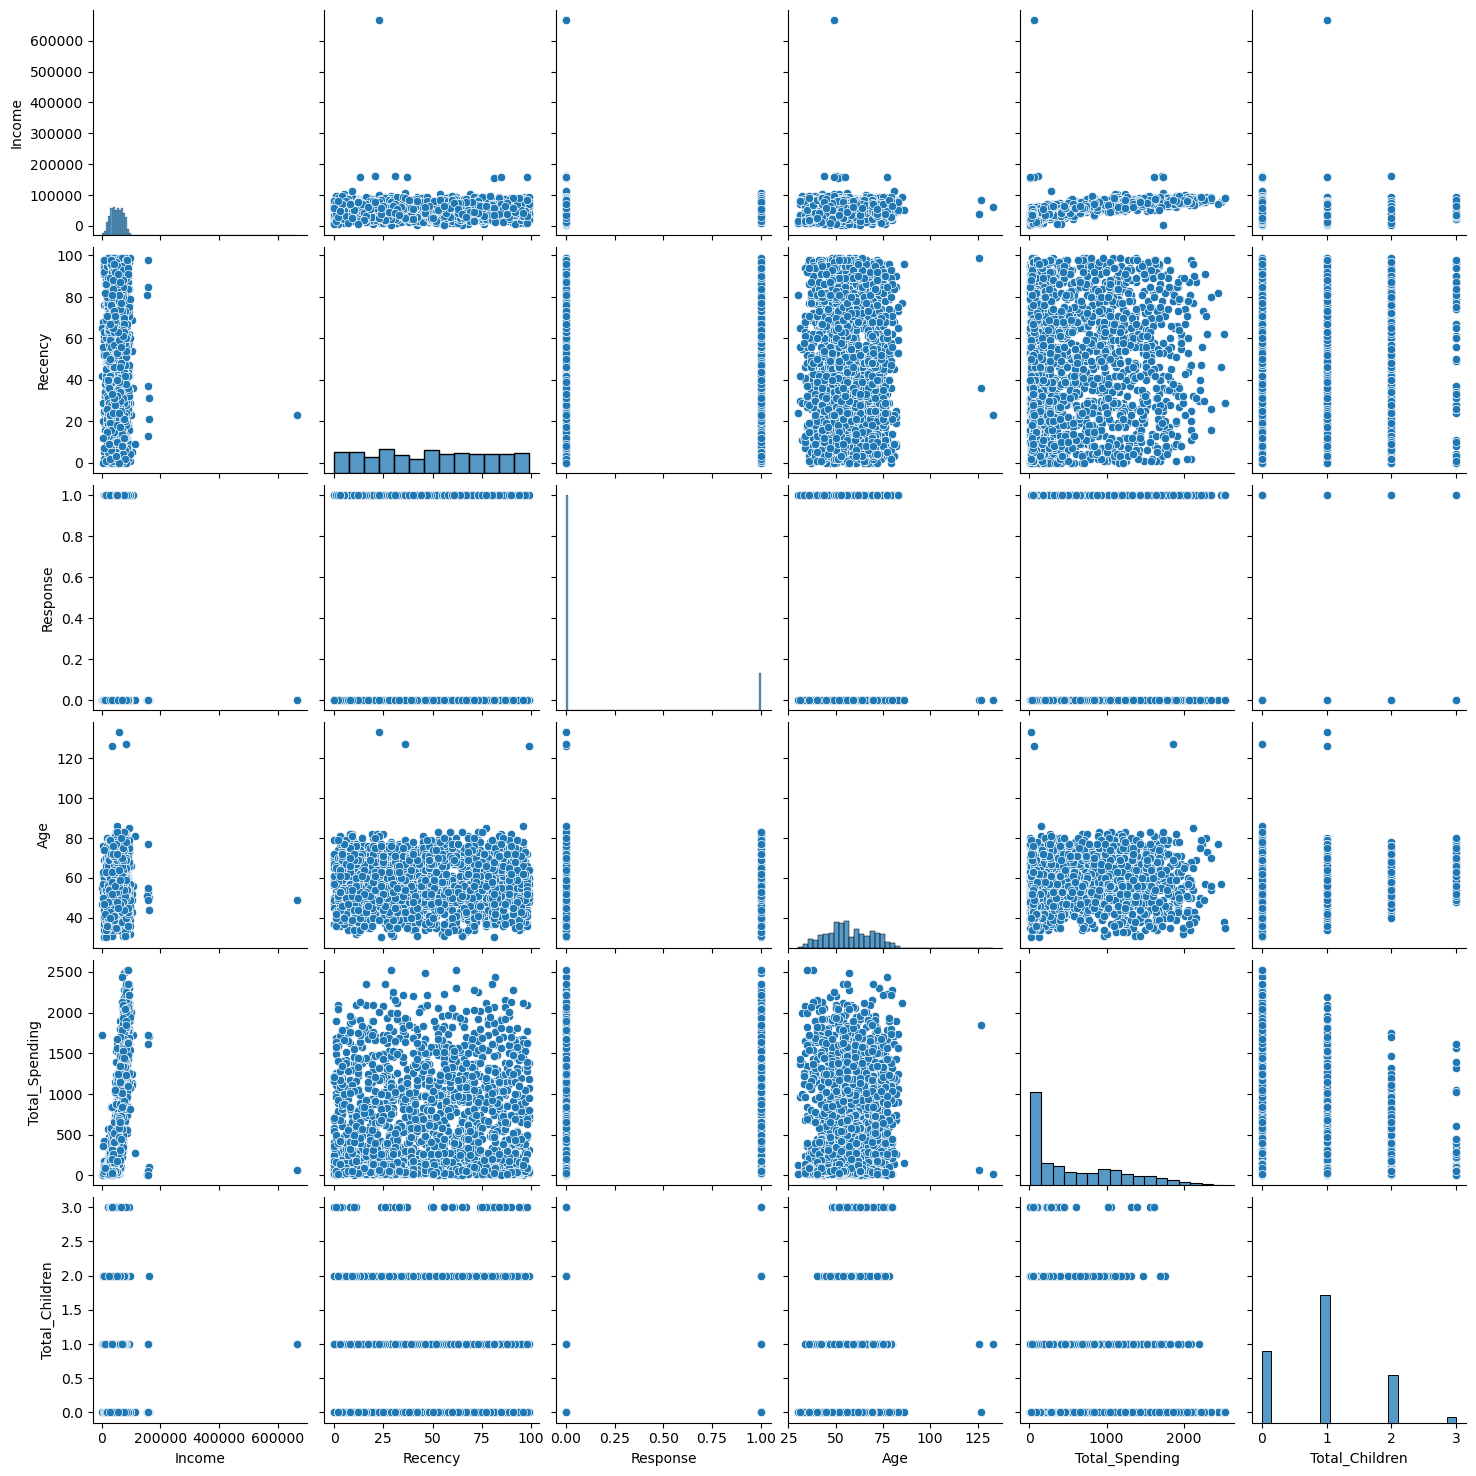

In [147]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [148]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# Heatmap

In [149]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

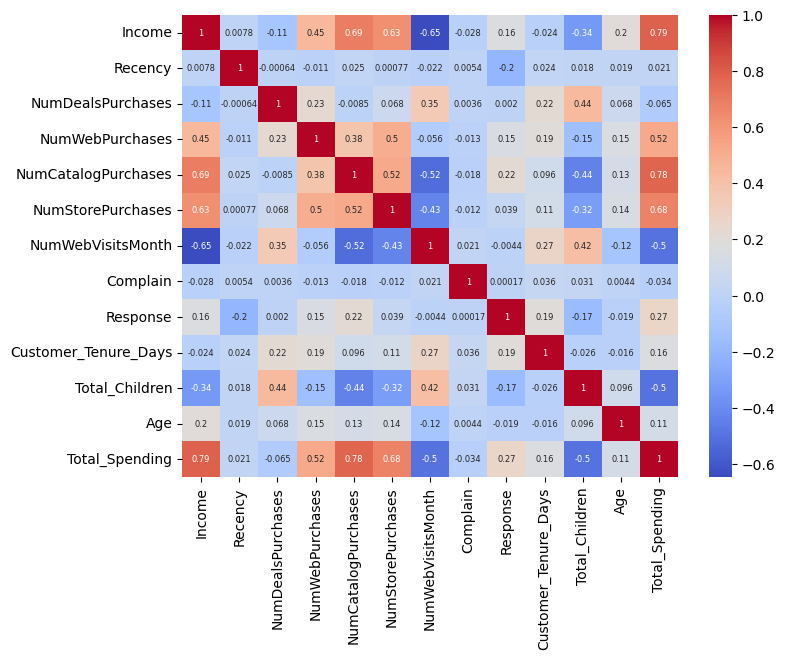

In [150]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

In [151]:
df_cleaned.shape

(2236, 15)

In [153]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Total_Children,Age,Total_Spending,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,663,0,69,1617,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,113,2,72,27,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,312,0,61,776,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,139,1,42,53,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,161,1,45,422,Partner


# Encoding

In [106]:
from sklearn.preprocessing import OneHotEncoder


In [154]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [155]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [156]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)


In [157]:
df_encoded.shape

(2236, 18)

In [158]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Total_Children,Age,Total_Spending,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,663,0,69,1617,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,113,2,72,27,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,312,0,61,776,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,139,1,42,53,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,161,1,45,422,0.0,1.0,0.0,0.0,1.0


# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [165]:
X = df_encoded

In [166]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [170]:
X_scaled.shape

(2236, 18)

In [173]:
# 2D visualization

from sklearn.decomposition import PCA

In [181]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d Projection')

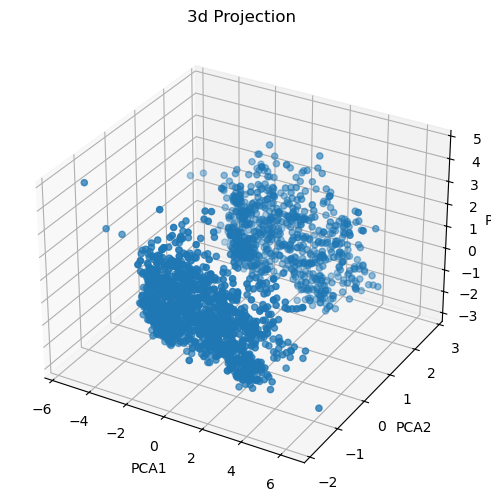

In [209]:
# Plot

fig = plt.figure(figsize=(9, 6))


ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")


# Analyze K-Value

### 1. Elbow Method

In [239]:
from sklearn.cluster import KMeans 
from kneed import KneeLocator  # Fixed spelling

WCSS = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    WCSS.append(kmeans.inertia_)


In [246]:
knee = KneeLocator(range(1, 11), WCSS, curve="convex", direction="decreasing")
optimal_k = knee.elbow

print("Best k =", optimal_k) # Fixed case-sensitivity


Best k = 4


Text(0, 0.5, 'WCSS')

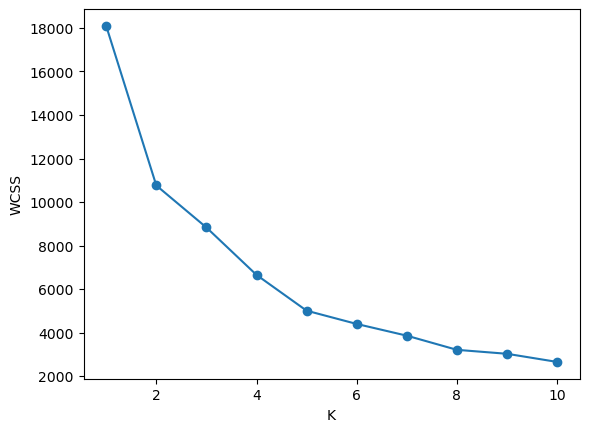

In [248]:
#Plot
plt.plot(range(1, 11), WCSS, marker ='o')
plt.xlabel('K')
plt.ylabel("WCSS")

## 2. Silhouette Score


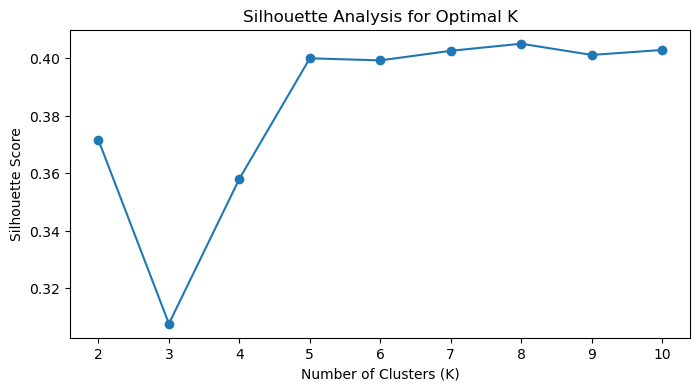

In [257]:
from sklearn.metrics import silhouette_score
scores = []

# Range adjusted to 2-10 to match your intended plot
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca) 
    score = silhouette_score(X_pca, labels)
    scores.append(score)
    
# Plot
plt.figure(figsize=(8, 4))

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal K")
plt.show()

Text(0, 0.5, 'SS')

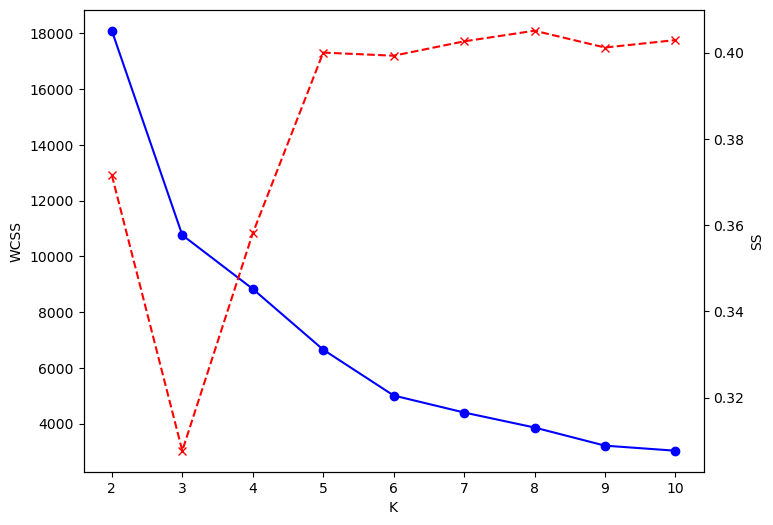

In [261]:
# Combined Plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, WCSS[:len(k_range)], marker = "o", color="Blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# Clustering


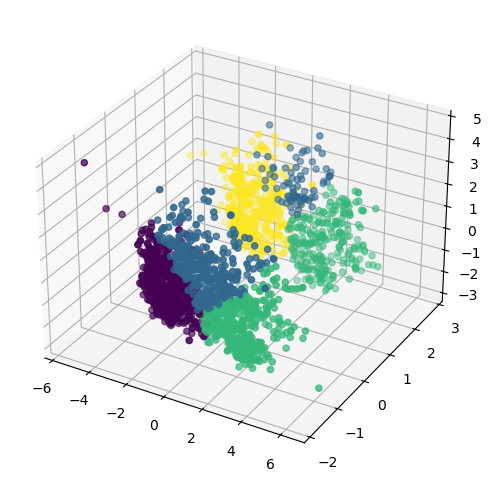

In [262]:
# K_means

from sklearn.cluster import KMeans 
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)


# Plot

fig = plt.figure(figsize=(9, 6))


ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [263]:
# Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering(n_clusters=4, linkage="ward")

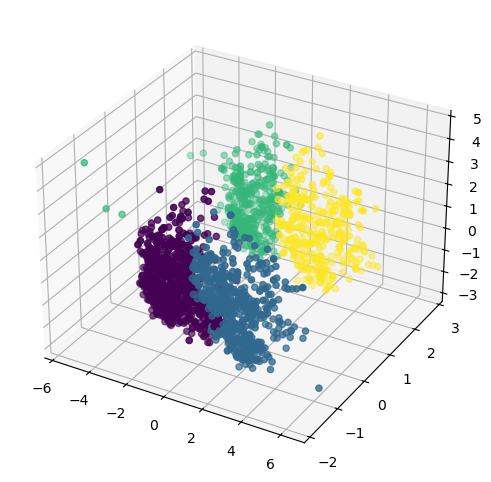

In [264]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))


ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

# Charecterization of clusters

In [284]:

X["cluster"] = labels_agg

In [285]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Total_Children,Age,Total_Spending,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,663,0,69,1617,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,113,2,72,27,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,312,0,61,776,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,139,1,42,53,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,161,1,45,422,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

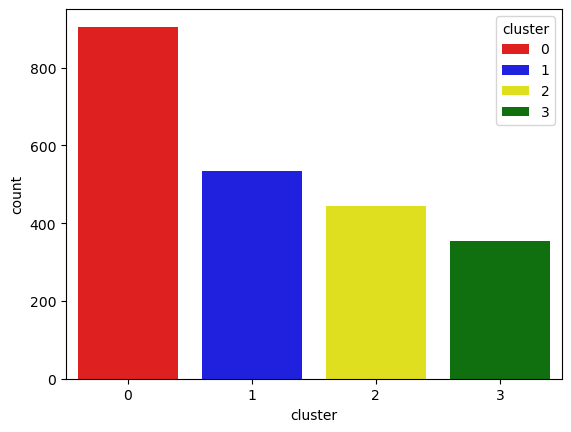

In [286]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

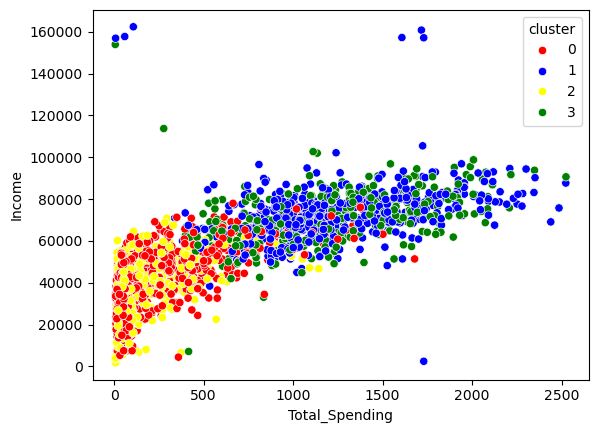

In [287]:
# Income & Spending pattern

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)


In [288]:
#Cluster Summary 

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response  Customer_Tenure_Days  Total_Children        Age  \
cluster         